# Introduction to neural network classification with TensorFlow

In this notebook we're going to learn how to write neural networks for classification problems.

A Classification is where you try to classify something as one thing or another.

A few types of classification problems:
* Binary classification
* Multiclass classification
* Multilabel classification

# Creating data to view and fit

In [ ]:
from sklearn.datasets import make_circles

#Make 1000 examples
n_samples = 1000

# Create circles
X , y = make_circles(n_samples,
                     noise=0.03,
                     random_state=42)

In [ ]:
#Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
#Check out labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

Our data is a little hard to understand right now... let's visualize it!

In [ ]:
import pandas as pd
circles = pd.DataFrame({"X0" : X[: , 0] , "X1" : X[: , 1]})
circles

,X0,X1
0,0.754246,0.231481
1,-0.756159,0.153259
2,-0.815392,0.173282
3,-0.393731,0.692883
4,0.442208,-0.896723
...,...,...
995,0.244054,0.944125
996,-0.978655,-0.272373
997,-0.136900,-0.810012
998,0.670362,-0.767502


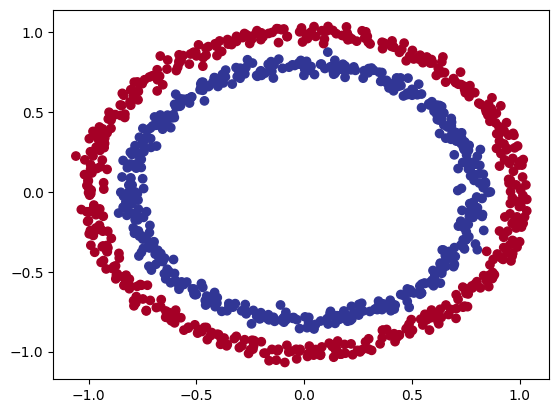

In [ ]:
#Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(X[: , 0] , X[: , 1] , c=y , cmap=plt.cm.RdYlBu);

# Input and output shapes

In [ ]:
#Check the shapes of our features and labels
X.shape , y.shape

((1000, 2), (1000,))

In [ ]:
#How many samples we're working
len(X) , len(y)

(1000, 1000)

In [ ]:
#View the first example of features and labels
X[0] , y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

# Steps in modelling

The stpes in modelling with TensorFlow are typically:
1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate...

In [ ]:
# Import tensorflow
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model]
model_1.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["accuracy"])

# 3. Fit the model
model_1.fit(X, y , epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4475 - loss: 5.4364
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4400 - loss: 4.9376
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4431 - loss: 4.5657
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4686 - loss: 2.8286
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4872 - loss: 0.7216


In [ ]:
#Let's try and improve our model by training for longer...
model_1.fit(X , y , epochs=200 , verbose=0)
model_1.evaluate(X , y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4852 - loss: 0.6927  


[0.6932879686355591, 0.4729999899864197]

Since we're working on a binary classification problem our model is getting around 50% accuracy... it's performing as if it's guessing.

So let's step things up a notch and add an extra layer.  

In [ ]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create a model , this time with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2.Compile the model
model_2.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["accuracy"])

# 3. Fit the model
model_2.fit(X , y , epochs=100 , verbose=0)

In [ ]:
# 4. Evaluate the model
model_2.evaluate(X , y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4955 - loss: 0.6931


[0.6933305263519287, 0.5]

#Improving our model

Let's look into our bag of tricks to see how we can improve our model.
1. Create a model - we might to add more layers or increase the number of hidden units within a layer.
2. Compiling a model - here we might to choose a different optimization function such as Adam instead of SGD.
3. Fitting a model - perhaps we might fit our model for more epochs (leave it training for longer).

In [ ]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100), # Add 100 dense neurons
    tf.keras.layers.Dense(10), # add another layer with 10 neurons
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# 3. Fit the model
model_3.fit(X , y , epochs=100 , verbose=0)

In [ ]:
# 4. Evaluate the model
model_3.evaluate(X , y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5086 - loss: 0.6915


[0.6951199173927307, 0.49000000953674316]

To visualize our model's predictions, let's create a function `plot_decision_boundary()` , this function will:
* Take a trained model, features(X) and labels(y)
* Create a meshgrid of different X values
* Make predictions across the meshgrid
* Plot the predictions as well as line between zones(where each unique class falls)

In [ ]:
import numpy as np

In [ ]:
def plot_decision_boundary(model , X , y):
  """

  Plots the decision boundary created by a model predicting on X
  """

  #Define the axis boundaries of the plot and create a meshgrid
  x_min , x_max = X[: , 0].min() - 0.1 , X[: , 0].max() + 0.1
  y_min , y_max = X[: , 1].min() - 0.1 , X[: , 1].max() + 0.1
  xx , yy = np.meshgrid(np.linspace(x_min , x_max , 100),
                        np.linspace(y_min , y_max , 100))

  #Create X value (we're going to make predictions on these)
  x_in = np.c_[xx.ravel() , yy.ravel()] # Stack 2D arrays together

  #Make predictions
  y_pred = model.predict(x_in)

  #Check for multi-class
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
    #We have to reshape our prediction to get them ready for plotting
    y_pred = np.argmax(y_pred , axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  #Plot the decision boundary
  plt.contourf(xx, yy , y_pred , cmap=plt.cm.RdYlBu , alpha=0.7)
  plt.scatter(X[: , 0] , X[: , 1] , c=y , s=40 , cmap = plt.cm.RdYlBu)
  plt.xlim(xx.min() , xx.max())
  plt.ylim(yy.min() , yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


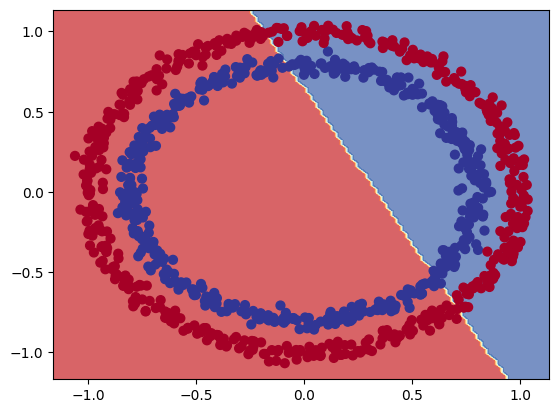

In [ ]:
#Check out the predictions our model is making
plot_decision_boundary(model = model_3,
                       X = X,
                       y = y)

In [ ]:
#Let's see if our model can be used for a regression problem...
tf.random.set_seed(42)

#Create some regression data
X_regression = tf.range(0 , 1000 , 5)
y_regression = tf.range(100 , 1100 , 5) # y = X+10

#Split our regression data into training and test sets
x_reg_train = X_regression[:150]
x_reg_test = X_regression[150:]
y_reg_train = y_regression[:150]
y_reg_test = y_regression[150:]

# Reshape X data to fit the model input requirements (min_ndim=2)
x_reg_train = tf.expand_dims(x_reg_train, axis=-1)
x_reg_test = tf.expand_dims(x_reg_test, axis=-1)

#Fit our model to the regression data
model_3.fit(x_reg_train , y_reg_train , epochs=100)

Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_3" is incompatible with the layer: expected axis -1 of input shape to have value 2, but received input with shape (None, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 1), dtype=int32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Oh wait... we compiled our model for a binary classification problem.

But... we're working on a regression problem , let's change the model to suit our data.

In [ ]:
# Setup the random seed
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2 Compile the model, this time with regression-specific loss function
model_3.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["mae"])

# 3. Fit the model
model_3.fit(x_reg_train , y_reg_train , epochs=100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 415.4030 - mae: 415.4030
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 336.8547 - mae: 336.8547 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 255.3052 - mae: 255.3052 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 169.2018 - mae: 169.2018 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 78.5310 - mae: 78.5310
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 54.1783 - mae: 54.1783 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 74.8090 - mae: 74.8090 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 60.6056 - mae: 60.6056 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 42.3245 - mae: 42.3245 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 46.3908 - mae: 46.3908  
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 40.3004 - mae: 40.3004 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 42.6711 - mae: 42.6711 
Epoch 13/100
5/5

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


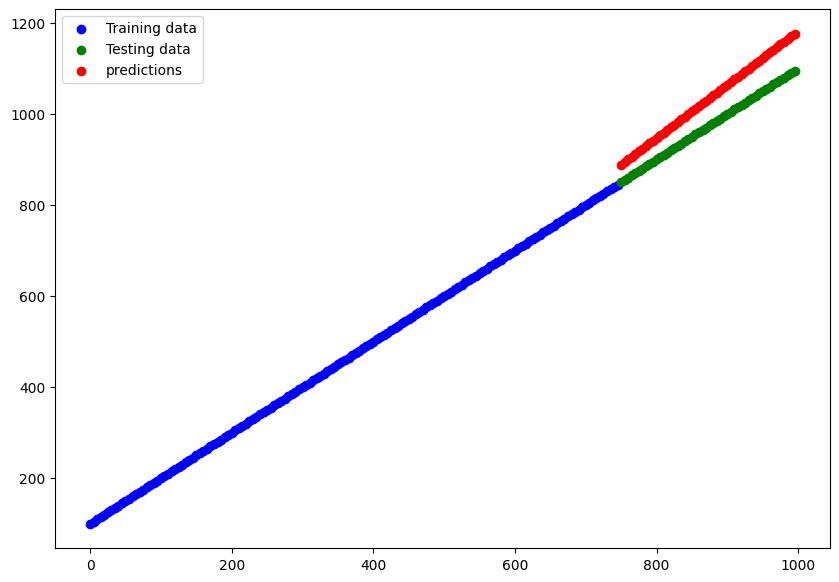

In [ ]:
#Make some predictions with our trained model
y_preds_reg = model_3.predict(x_reg_test)

# Plot the model's predictions against our regression data
plt.figure(figsize=(10,7))
plt.scatter(x_reg_train , y_reg_train , c="b" , label = "Training data")
plt.scatter(x_reg_test , y_reg_test , c="g" , label = "Testing data")
plt.scatter(x_reg_test , y_preds_reg , c="r" , label = "predictions")
plt.legend();

# The missing piece: Non-linearity

In [ ]:
#Set the random seed
tf.random.set_seed(42)

# 1.Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1 , activation=tf.keras.activations.linear)
])

# 2. COmpile the model
model_4.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics = ["accuracy"])

# 3. Fit the model
history = model_4.fit(X , y , epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5081 - loss: 5.9248
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5081 - loss: 5.9164
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5081 - loss: 5.9163
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5081 - loss: 5.9163
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5081 - loss: 5.9163
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5081 - loss: 5.9163
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5081 - loss: 5.9162
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5081 - loss: 5.9162
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5081 - loss: 5.9162
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5081 - loss: 5.9161
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5081 - loss: 5.9161
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

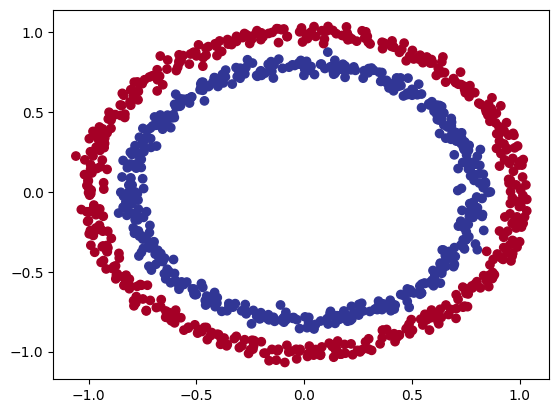

In [ ]:
#Check out our data
plt.scatter(X[: , 0] , X[: , 1] , c=y , cmap=plt.cm.RdYlBu)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


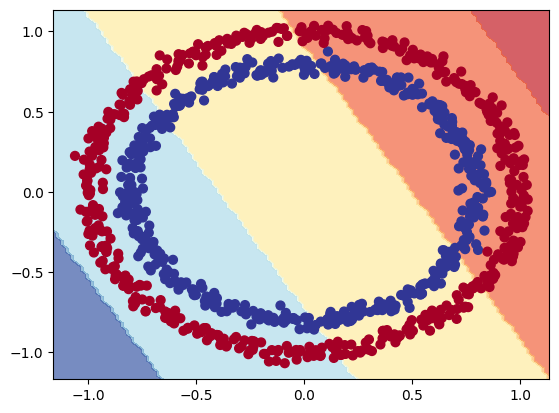

In [ ]:
# Check the decision boundary for our latest model
plot_decision_boundary(model = model_4,
                       X = X,
                       y = y)

Let's try our first neural network with a non-linear activation function

In [ ]:
#set the random seed
tf.random.set_seed(42)

# 1 Create a model wirh a non-linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1 , activation="relu")
])

# 2. Compile the model
model_5.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics = ["accuracy"])

# 3. Fit the model
history = model_5.fit(X , y , epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4509 - loss: 5.0074
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4489 - loss: 4.9580 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4467 - loss: 4.8931
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4471 - loss: 4.8522
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4458 - loss: 4.8427
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4468 - loss: 4.8350
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4468 - loss: 4.8284
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4488 - loss: 4.8226
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4433 - loss: 4.8175 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4415 - loss: 4.8129
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4441 - loss: 4.8076
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accurac

In [ ]:
#Time to replicate the multi-layer neural network from TensorFlow palyground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_6.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics = ["accuracy"])

# 3. Fit the model
history = model_6.fit(X , y , epochs=250)

Epoch 1/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3924 - loss: 3.0368
Epoch 2/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4494 - loss: 1.3021
Epoch 3/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4557 - loss: 1.2102
Epoch 4/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4594 - loss: 1.1481
Epoch 5/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4591 - loss: 1.0834
Epoch 6/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4595 - loss: 1.0046
Epoch 7/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4610 - loss: 0.9513
Epoch 8/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4643 - loss: 0.9167
Epoch 9/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4638 - loss: 0.8908
Epoch 10/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4663 - loss: 0.8700
Epoch 11/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4663 - loss: 0.8527
Epoch 12/250
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [ ]:
# Evaluate our model
model_6.evaluate(X , y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9654 - loss: 0.1410


[0.12831148505210876, 0.9739999771118164]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


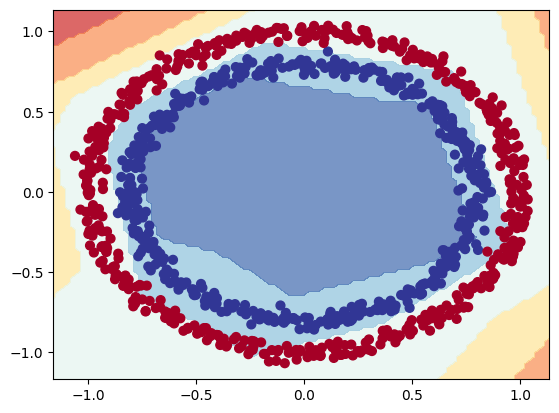

In [ ]:
#How do our model predictions look
plot_decision_boundary(model = model_6,
                       X = X,
                       y = y)

In [ ]:
# set the random seed
tf.random.set_seed(42)

# 1.Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])
# 2. compile the model
model_7.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics = ["accuracy"])

# 3. Fit the model
history = model_7.fit(X , y , epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4712 - loss: 0.6989
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4755 - loss: 0.6945
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4775 - loss: 0.6916
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4769 - loss: 0.6895
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4834 - loss: 0.6879
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4922 - loss: 0.6866
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4911 - loss: 0.6856
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4974 - loss: 0.6847
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5032 - loss: 0.6839
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5058 - loss: 0.6832
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5102 - loss: 0.6825
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [ ]:

# Evaluate our model
model_7.evaluate(X , y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9800 - loss: 0.2533


[0.25137513875961304, 0.9760000109672546]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


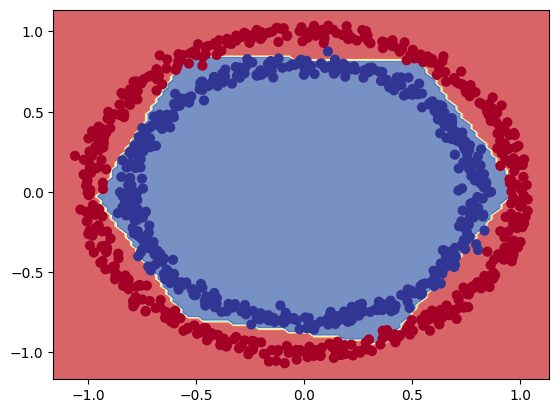

In [ ]:
#Let's visualize our metrics
plot_decision_boundary(model_7 , X, y)

**Note:** The combination of **linear (straight lines) and non-linear (non-straight lines) functions** is one of the key fundamentals of neural networks.

Now we've discussed the concept of linear and non-linear functions(or lines), let's see them in action.

In [ ]:
#Create a toy tensor (similar to the data we pass into our models)
A = tf.cast(tf.range(-10 , 10) , tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

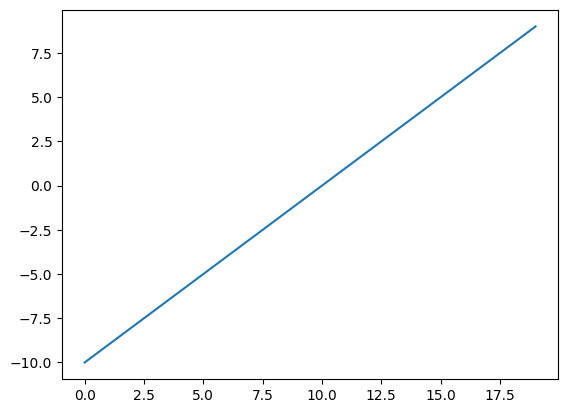

In [ ]:
#Visualize our toy tensor
plt.plot(A)

In [ ]:
#Let's start by replicating sigmoid - sigmoid(x) = 1 / (1 + exp(-x))
def sigmoid(x):
  return 1 / (1 + tf.exp(-x))

# Use the sigmoid function on our toy tensor
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

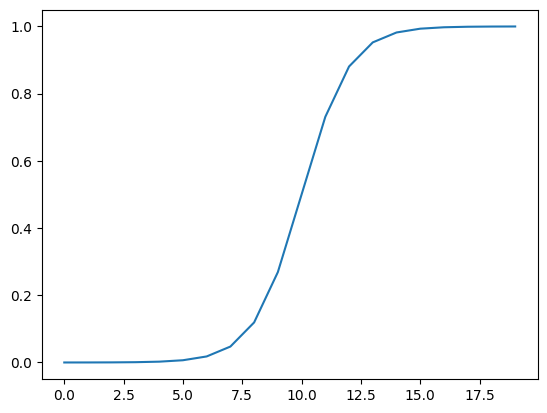

In [ ]:


#Let's plot our toy tensor transformed by sigmoid
plt.plot(sigmoid(A))

In [ ]:
#Let's recreate the relu function
def relu(x):
  return tf.maximum(0 , x)

# Pass our toy tensor to our custom relu function
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

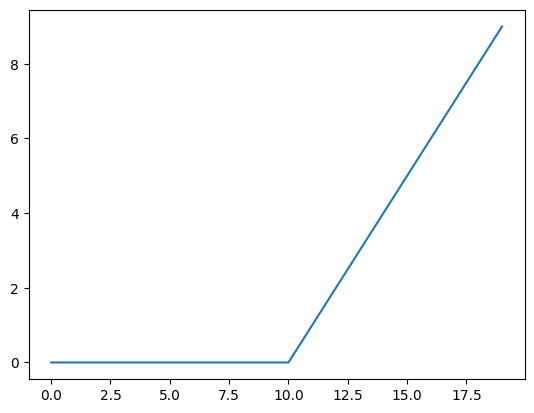

In [ ]:
#Plot ReLU-modified tensor
plt.plot(relu(A))

In [ ]:
#Let's try the linear activation function
tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

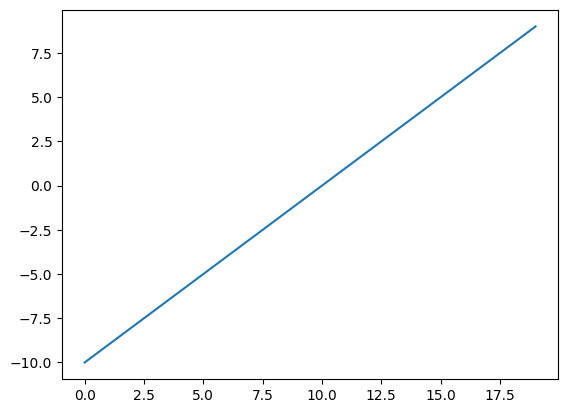

In [ ]:

# Does the linear activation function change anything?
plt.plot(tf.keras.activations.linear(A))

In [ ]:
# Does A even change ?
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

#Evaluating and improving our classification

So far we've been training and testing on the same dataset...

However, in machine learning this is basically a sin.

So let's create a training and test set.

In [ ]:
len(X)

1000

In [ ]:
#Split into train and test set
x_train ,  y_train = X[:800] , y[:800]
x_test , y_test = X[800:] , y[800:]

x_train.shape , x_test.shape , y_train.shape , y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [ ]:
  #Let's recreate a model to fit on the training data and evaluate on the testing data

#Set the random seed
tf.random.set_seed(42)

#1. Create the model (same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])

#2. Compile the model
model_8.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics = ["accuracy"])

#3. Fit the model
history = model_8.fit(x_train , y_train , epochs=25)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5173 - loss: 0.6912
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5220 - loss: 0.6816 
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5504 - loss: 0.6756 
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5569 - loss: 0.6666 
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5904 - loss: 0.6557 
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6203 - loss: 0.6397
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6828 - loss: 0.6131 
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7431 - loss: 0.5783 
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8046 - loss: 0.5362 
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8253 - loss: 0.4917 
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8720 - loss: 0.4306 
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.

In [ ]:
#4.Evaluate the model on the test dataset
model_8.evaluate(x_test , y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9950 - loss: 0.0496  


[0.048668280243873596, 0.9950000047683716]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


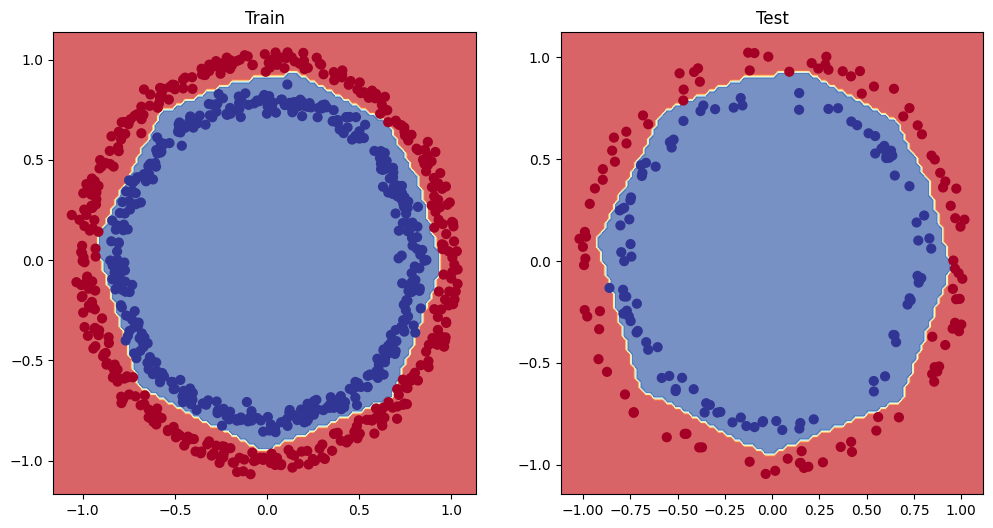

In [ ]:

#Plot the decision boundaries for the training and test set
plt.figure(figsize=(12,6))
plt.subplot(1 , 2 , 1)
plt.title("Train")
plot_decision_boundary(model = model_8 , X=x_train , y=y_train)
plt.subplot(1 , 2 , 2)
plt.title("Test")
plot_decision_boundary(model = model_8 , X=x_test , y=y_test)
plt.show();

#Plot the loss(or training)curves

In [ ]:

#Convert the history object into DataFrame
pd.DataFrame(history.history)

,accuracy,loss
0,0.54375,0.686699
1,0.54500,0.677171
2,0.59125,0.669014
3,0.59750,0.658886
4,0.64750,0.646578
5,0.68250,0.628748
6,0.72500,0.601046
7,0.76625,0.564434
8,0.81500,0.521290
9,0.83375,0.474986


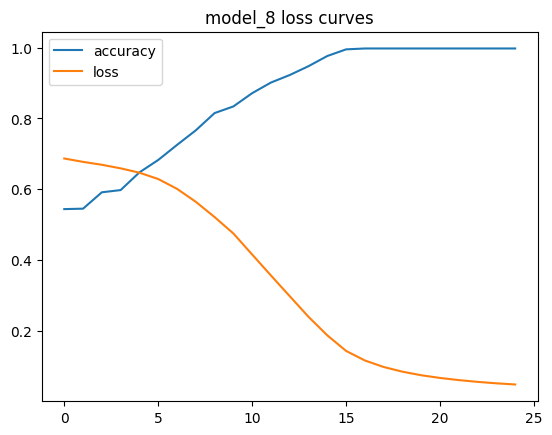

In [ ]:
#Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("model_8 loss curves");

**Note:** For many problems, the loss function going down means the model is improving(the predictions it's making are getting ground truth labels).

#Finding the best learning rate

To find the ideal learning rate (the learning rate where the loss decreases the most during training) we're going to use the following steps:
* A learning rate **callback** - you can think of a callcack as an extra piece of functionality , you can add to your *while* it's training.
* Another model (we could use the same one as above , but we're practicing building models here)
* A modified loss curves plot.

In [ ]:

#Set the random seed
tf.random.set_seed(42)

# Create a model (same as model_8)
model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(4 , activation = "relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])
# Compile the model
model_9.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch : 1e-4 * 10**(epoch/20))

#Fit the model (passing lr_scheduler callback)
history_9 = model_9.fit(x_train,
                        y_train,
                        epochs=100,
                        callbacks=[lr_scheduler])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5094 - loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5158 - loss: 0.6929 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5205 - loss: 0.6929 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5187 - loss: 0.6928 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5187 - loss: 0.6927 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5163 - loss: 0.6927 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5246 - loss: 0.6926 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5229 - loss: 0.6925 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5251 - loss: 0.6924 - learning_

<Axes: xlabel='epochs'>

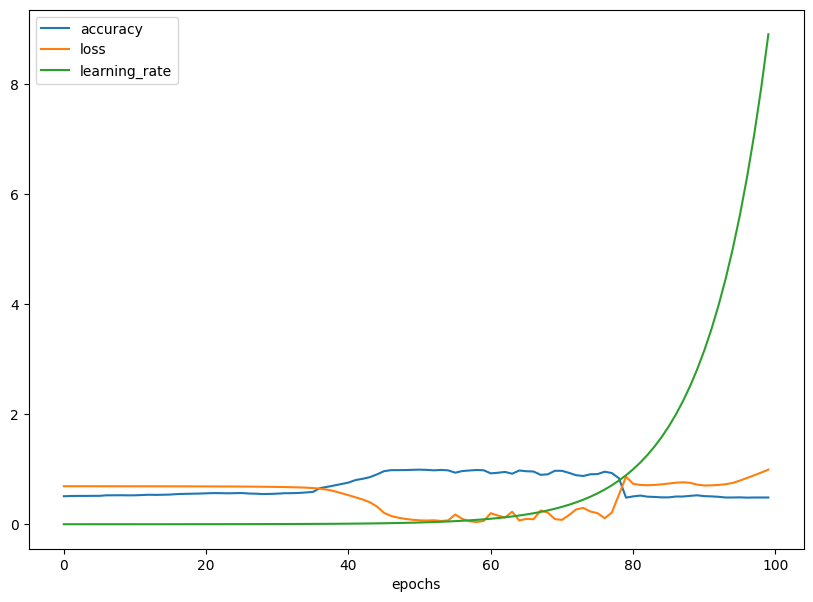

In [ ]:

#Checkout the history
pd.DataFrame(history_9.history).plot(figsize=(10,7),
                                     xlabel="epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

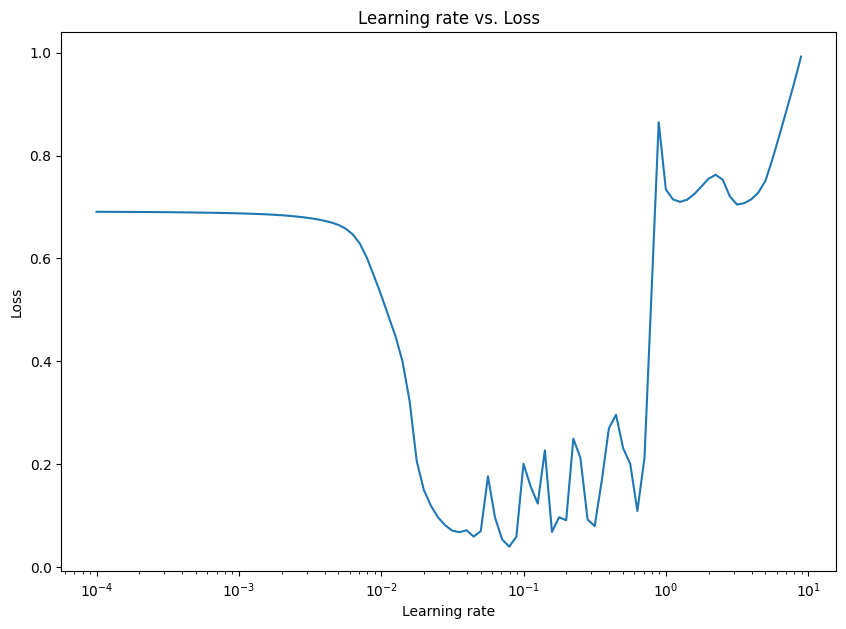

In [ ]:
#Plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100) / 20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs , history_9.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")

In [ ]:

#Let's try using a higher *ideal* learning rate with the same model as before

#Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(1 , activation="sigmoid")
])
# 2. Compile the model
model_10.compile(loss = tf.keras.losses.BinaryCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(learning_rate=0.02),
                 metrics = ["accuracy"])

# 3. Fit the model
history = model_10.fit(x_train , y_train , epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5890 - loss: 0.6872
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6692 - loss: 0.6541 
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7432 - loss: 0.6015 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8422 - loss: 0.5152
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8751 - loss: 0.4064 
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9383 - loss: 0.3006 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9599 - loss: 0.2114
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9947 - loss: 0.1378 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9918 - loss: 0.1067
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9956 - loss: 0.0890 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9938 - loss: 0.0743 
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.99

In [ ]:
#Evaluate model_10
model_10.evaluate(x_test , y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0238  


[0.024603979662060738, 1.0]

In [ ]:
#Evaluate model_8
model_8.evaluate(x_test , y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9950 - loss: 0.0496 


[0.048668280243873596, 0.9950000047683716]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


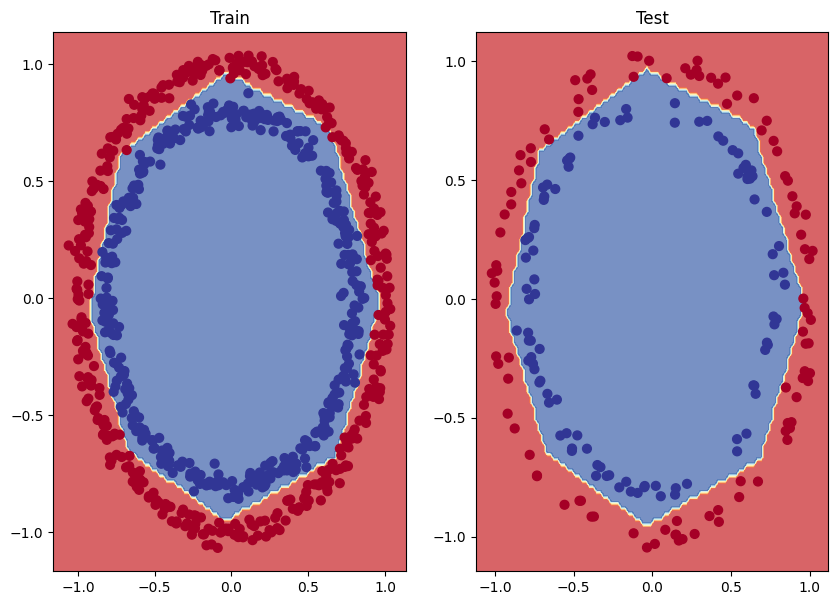

In [ ]:
#Plot the decision boundaries for the training and test sets
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model = model_10 , X=x_train , y=y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model=model_10 , X=x_test , y=y_test)
plt.show();

#More classification evaluation methods

Alongside visualizing our models results as much as possible,there are a handful of other classification evaluation methods & metrics you should be familiar with:
* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report (from scikit-learn)

In [ ]:
#Check the accuracy of our model
loss , accuracy = model_10.evaluate(x_test , y_test)
print(f"Model loss on the test set: {loss}")
print(f"Model accuracy on the test set: {(accuracy*100):.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0238 
Model loss on the test set: 0.024603979662060738
Model accuracy on the test set: 100.00%


#How about confusion matrix ?

In [ ]:
from sklearn.metrics import confusion_matrix

#Make some predictions
y_preds = model_10.predict(x_test)

#Make the confusion matrix
confusion_matrix(y_test , y_preds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
y_test[:10]

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 0])

In [ ]:
y_preds[:10]

array([[9.9537891e-01],
       [9.9862951e-01],
       [9.9904984e-01],
       [9.9674189e-01],
       [7.9705149e-02],
       [1.9270698e-04],
       [9.9903768e-01],
       [8.3493098e-04],
       [9.9415708e-01],
       [3.5281342e-03]], dtype=float32)

Oops... looks like our predictions array has come out in **prediction probability** form... the standard output form the sigmoid(or softmax) activation functions.

In [ ]:

#Convert prediction probabilities to binary format and view the first 10
tf.round(y_preds)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [ ]:
#Recreate our confusion matrix
confusion_matrix(y_test , tf.round(y_preds))

array([[101,   0],
       [  0,  99]])

# How about we prettify our confusion matrix?

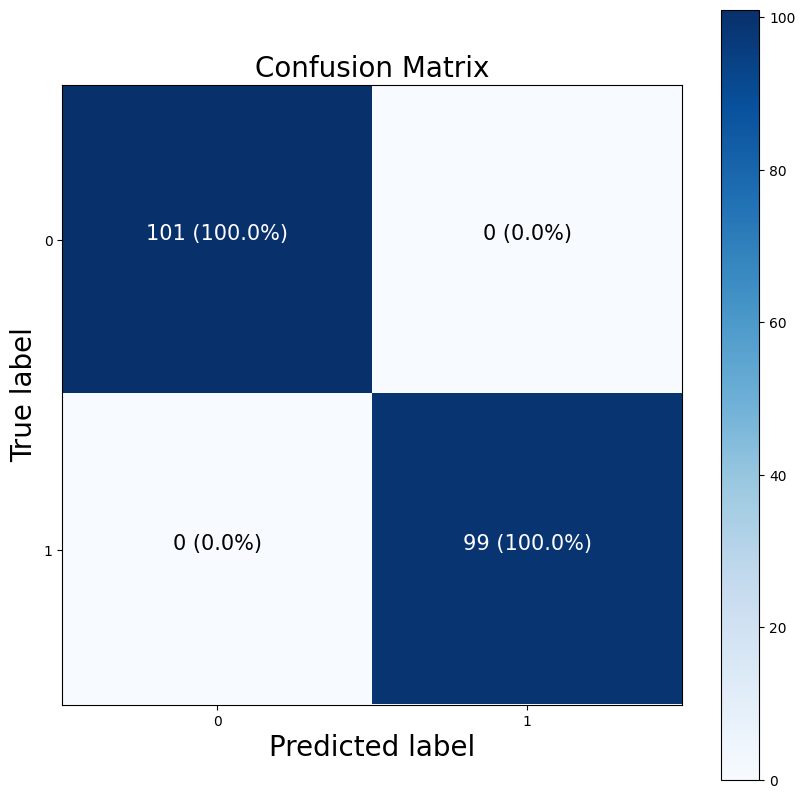

In [ ]:
import itertools

figsize = (10,10)

#Create the confusion matrix
cm = confusion_matrix(y_test , tf.round(y_preds))
cm_norm = cm.astype("float") / cm.sum(axis=1)[: , np.newaxis] # normalize our confusion matrix
n_classes = cm.shape[0]

#Let's prettify it
fig , ax = plt.subplots(figsize=figsize)
#Create a matrix plot
cax = ax.matshow(cm , cmap=plt.cm.Blues)
fig.colorbar(cax)

#Create classes
classes = False
if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

#label the axes
ax.set(title = "Confusion Matrix",
       xlabel = "Predicted label",
       ylabel = "True label",
       xticks = np.arange(n_classes),
       yticks = np.arange(n_classes),
       xticklabels = labels,
       yticklabels = labels)

# Set x-axis labels to bottom
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

#Adjust label size
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
ax.title.set_size(20)

#Set the threshold for different colors
threshold = (cm.max() + cm.min()) / 2.

#Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j , i , f"{cm[i ,j]} ({cm_norm[i , j]*100:.1f}%)",
           horizontalalignment = "center",
           color = "white" if cm[i , j] > threshold else "black",
           size = 15)



In [ ]:
cm_norm

array([[1., 0.],
       [0., 1.]])

In [ ]:
cm.shape[0]

2

#Working with a larger example (multiclass classification)

When you have more than two classes as an option, it's known as **multi-class classification**.
* This means if you have 3 different classes, it's multi-class classification.
* It also means if you have 100 different classes, it's multi-class classification.

To practice multi-class classification , we're going to build a neural network to classify images of different items of clothing.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us
(train_data , train_labels) , (test_data , test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Show the first training example
print(f"Training sample: \n{train_data[0]}\n")
print(f"Training label: \n{train_labels[0]}\n")

Training sample: 
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1 

In [ ]:
#Check the shape of a single example
train_data[0].shape , train_labels[0].shape

((28, 28), ())

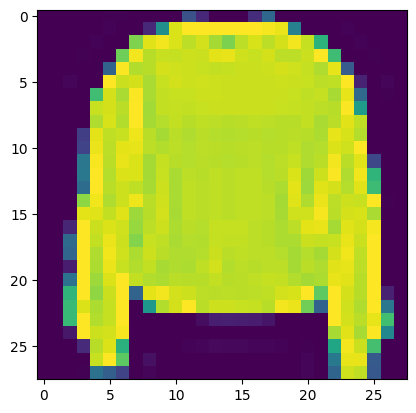

In [ ]:
#Plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[7]);

In [ ]:
#check out samples label
train_labels[7]

np.uint8(2)

In [ ]:
#Create a small list so we can index onto our training labels so they're human-readable
class_names = ["T-shirt/top" , "Trouser" , "Pullover" , "Dress" , "Coat" , "Sandal" , "Shirt" , "Sneaker" , "Bag" , "Ankle boot"]

len(class_names)

10

Text(0.5, 1.0, 'Dress')

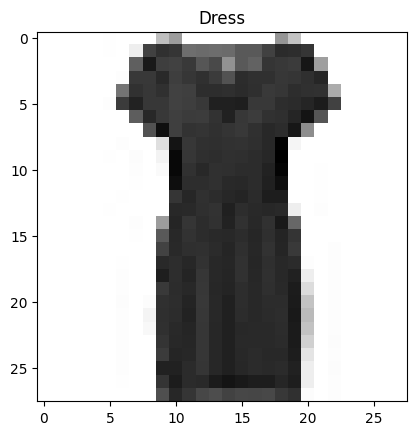

In [ ]:
#Plot an example image and it's label
index_of_choice = 20
plt.imshow(train_data[index_of_choice] , cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

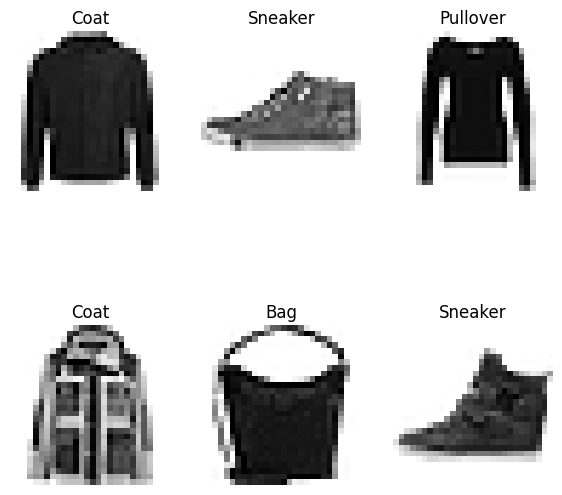

In [ ]:
#Plot multiple random images of fashion MNIST
import random
plt.figure(figsize=(7,7))
for i in range(6):
  ax = plt.subplot(2,3, i+1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index] , cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

#Building a multi-class classification model

For our multi-class classification model, we can use a similar architechture to our binary classifiers,however, we're going to have a tweak a few things:
* Input shape = 28 x 28 (the shape of one image)
* Output shape = 10 (one per class of clothing)
* Loss function = tf.keras.losses.CategoricalCrossentropy()
  * If your labels are one-hot encoded, use CategoricalCrossentropy()
  * If your labels are integer form use SparseCategoricalCrossentropy()
* Output layer activation = Softmax(not Sigmoid)

In [ ]:
#Our data needs to be flattened (from 28*28 to None, 784)
flatten_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28))
])
flatten_model.output_shape

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [ ]:
tf.one_hot(train_labels[:10] , depth=10)

<tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)>

In [ ]:
#Set the random seed
tf.random.set_seed(42)

#Create the model
model_11 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(4 , activation = "relu"),
    tf.keras.layers.Dense(10 , activation = tf.keras.activations.softmax)
])

#Compile the model
model_11.compile(loss = tf.keras.losses.CategoricalCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(),
                 metrics = ["accuracy"])

#Fit the model
non_norm_history = model_11.fit(train_data,
                                tf.one_hot(train_labels , depth=10),
                                epochs=10,
                                validation_data=(test_data , tf.one_hot(test_labels , depth=10)))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1404 - loss: 3.0085 - val_accuracy: 0.2381 - val_loss: 1.7980
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2532 - loss: 1.7404 - val_accuracy: 0.2748 - val_loss: 1.6388
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2772 - loss: 1.6381 - val_accuracy: 0.2774 - val_loss: 1.6161
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2790 - loss: 1.6244 - val_accuracy: 0.2750 - val_loss: 1.6122
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2745 - loss: 1.6129 - val_accuracy: 0.2760 - val_loss: 1.6045
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.2798 - loss: 1.6085 - val_accuracy: 0.3104 - val_loss: 1.5954
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2922 - loss: 1.5976 - val_accuracy: 0.3185 - val_loss: 1.5873
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3072 - loss: 1.5924 - 

In [ ]:
#Check the model summary
model_11.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [ ]:
#Check the min and max values of the training data
train_data.min() , train_data.max()

(np.uint8(0), np.uint8(255))

Neural networks prefer data to be scaled (or normalized), this means they like to have the numbers in the tensors they try to find patterns between 0 & 1.

In [ ]:
#We can get our training and testing data between 0 & 1 by dividing by the maximum
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

#Check the min and max values of the scaled training data
train_data_norm.min() , train_data_norm.max()

(np.float64(0.0), np.float64(1.0))

In [ ]:
# Now our data is normalized, let's build a model to find patterns in it

# Set the random seed
tf.random.set_seed(42)

# Create the model
model_12 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4 , activation="relu"),
    tf.keras.layers.Dense(4 , activation = "relu"),
    tf.keras.layers.Dense(10 , activation = "softmax")
])

#Compile the model
model_12.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy,
                 optimizer = tf.keras.optimizers.Adam(),
                 metrics = ["accuracy"])

#Fit the model
norm_history = model_12.fit(train_data_norm,
                            train_labels,
                            epochs=10,
                            validation_data=(test_data_norm , test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.2888 - loss: 1.7846 - val_accuracy: 0.5748 - val_loss: 1.0311
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6061 - loss: 0.9791 - val_accuracy: 0.6514 - val_loss: 0.8962
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6605 - loss: 0.8644 - val_accuracy: 0.7035 - val_loss: 0.8075
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7141 - loss: 0.7828 - val_accuracy: 0.7318 - val_loss: 0.7547
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7397 - loss: 0.7314 - val_accuracy: 0.7465 - val_loss: 0.7077
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7572 - loss: 0.6855 - val_accuracy: 0.7603 - val_loss: 0.6690
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7761 - loss: 0.6456 - val_accuracy: 0.7812 - val_loss: 0.6343
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7951 - loss: 0.6103 - 

> **Note:** Neural networks tend to prefer data in numerical form as well as scaled/normalized (numbers between 0 & 1).

<Axes: title={'center': 'Normalized data'}>

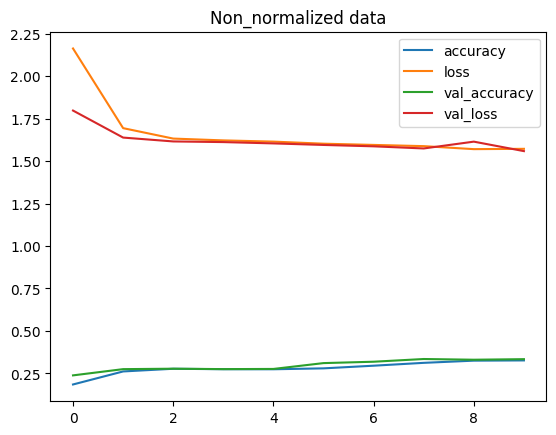

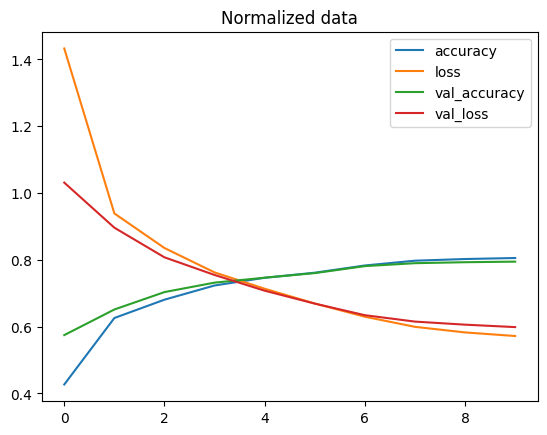

In [ ]:
import pandas as pd

#Plot non-normalized data loss curves
pd.DataFrame(non_norm_history.history).plot(title="Non_normalized data")
#Plot normlized data loss curves
pd.DataFrame(norm_history.history).plot(title = "Normalized data")

> **Note:** The same model with even *slightly* different data can produce dramatically different results. So when you're comparing models, it's important to make sure you're comparing them on the same criteria(e.g. same architecture but different data or same data but different architecture).

#Finding the ideal learning rate

In [ ]:
#Set the random seed
tf.random.set_seed(42)

#Create the model
model_13 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28)),
    tf.keras.layers.Dense(4 , activation = "relu"),
    tf.keras.layers.Dense(4 , activation = "relu"),
    tf.keras.layers.Dense(10 , activation = "softmax")
])
#Compile the model
model_13.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(),
                 metrics = ["accuracy"])

#Create the learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch : 1e-3 * 10 **(epoch/20))

#Fit the model
find_lr_history = model_13.fit(train_data_norm,
                               train_labels,
                               epochs=40,
                               validation_data = (test_data_norm , test_labels),
                               callbacks = [lr_scheduler])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3307 - loss: 1.7053 - val_accuracy: 0.6075 - val_loss: 0.9706 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6238 - loss: 0.9351 - val_accuracy: 0.6668 - val_loss: 0.8782 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6642 - loss: 0.8590 - val_accuracy: 0.6942 - val_loss: 0.8254 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6906 - loss: 0.8098 - val_accuracy: 0.7060 - val_loss: 0.8058 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7096 - loss: 0.7817 - val_accuracy: 0.7278 - val_loss: 0.7902 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7302 - loss: 0.7556 - val_accuracy: 0.7374 - val_loss: 0.7690 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7407 - l

Text(0.5, 1.0, 'Finding the ideal learning rate')

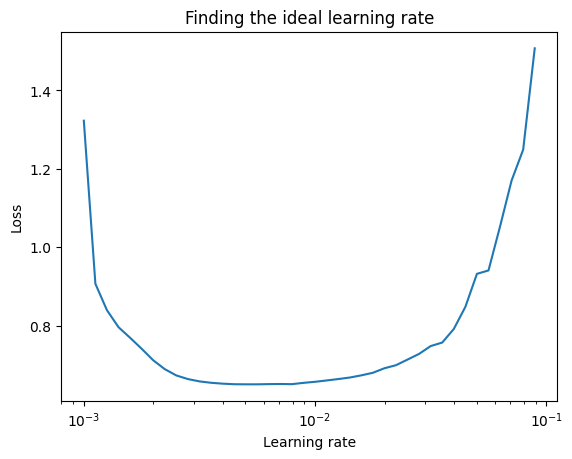

In [ ]:
#Plot the learning rate decay curve
import numpy as np
import matplotlib.pyplot as plt

lrs = 1e-3 * (10 ** (tf.range(40) / 20))
plt.semilogx(lrs , find_lr_history.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate")

In [ ]:
#Let's refit a model with the ideal learning rate

#Set the random seed
tf.random.set_seed(42)

#Create the model
model_14 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28)),
    tf.keras.layers.Dense(4 , activation = "relu"),
    tf.keras.layers.Dense(4 , activation = "relu"),
    tf.keras.layers.Dense(10 , activation = "softmax")
])
#Compile the model
model_14.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
                 metrics = ["accuracy"])

#Fit the model
history_14 = model_14.fit(train_data_norm,
                               train_labels,
                               epochs=20,
                               validation_data = (test_data_norm , test_labels))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4169 - loss: 1.5932 - val_accuracy: 0.6915 - val_loss: 0.8748
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7070 - loss: 0.8112 - val_accuracy: 0.7209 - val_loss: 0.7385
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7335 - loss: 0.7159 - val_accuracy: 0.7358 - val_loss: 0.6998
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7471 - loss: 0.6825 - val_accuracy: 0.7444 - val_loss: 0.6811
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7591 - loss: 0.6610 - val_accuracy: 0.7644 - val_loss: 0.6573
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7748 - loss: 0.6343 - val_accuracy: 0.7738 - val_loss: 0.6401
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7829 - loss: 0.6162 - val_accuracy: 0.7801 - val_loss: 0.6286
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7877 - loss: 0.6044 - 

#Evaluating our multi-class classification model

To evaluate our multi-class classification model we could:
* Evaluate it's performance using other classification metrics (such as confusion matrix)
* Assess some of it's predictions (through visualizations)
* Improve it's results (by training it for longer or changing the architecture)
* Save and export it for use in an application

Let's go through the top 2...

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_true , y_pred , classes=None , figsize=(10,10) , text_size=15):

  #Create the confusion matrix
  cm = confusion_matrix(y_true , y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[: , np.newaxis]
  n_classes = cm.shape[0]

  #Let's prettify it
  fig , ax = plt.subplots(figsize = figsize)
  #Create matrix plot
  cax = ax.matshow(cm , cmap=plt.cm.Blues)
  fig.colorbar(cax)

  #Set labels to be classes
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  #Label the axes
  ax.set(title = "Confusion Matrix",
         xlabel = "Predicted label",
         ylabel = "True label",
         xticks = np.arange(n_classes),
         yticks = np.arange(n_classes),
         xticklabels = labels,
         yticklabels = labels)

  #Set x-axis labels to bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  #Adjust label size
  ax.xaxis.label.set_size(text_size)
  ax.yaxis.label.set_size(text_size)
  ax.title.set_size(text_size)

  #Set the threshold
  threshold = (cm.max() + cm.min()) / 2

  #Plot the text in each cell
  for i , j in itertools.product(range(cm.shape[0]) , range(cm.shape[1])):
    plt.text(j , i , f"{cm[i , j]} ({cm[i , j]*100:.1f}%)",
    horizontalalignment = "center",
    color = "white" if cm[i , j] > threshold else "black",
    size = text_size)

In [ ]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [ ]:
#Make some predictions with our model
y_probs = model_14.predict(test_data_norm) # probs is short for "predcition probabilities"

#View the first 5 predcitions
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[1.1802847e-16, 5.9892940e-05, 6.5206645e-09, 8.7632580e-20,
        8.3507858e-09, 4.9628568e-01, 7.0075570e-11, 1.2306545e-01,
        3.8133896e-04, 3.8020766e-01],
       [3.0482242e-05, 3.3592610e-06, 8.7234086e-01, 3.3067796e-08,
        7.3727779e-02, 6.6752932e-08, 5.2405093e-02, 1.4582163e-03,
        1.9351777e-05, 1.4785555e-05],
       [5.4974842e-09, 9.9981213e-01, 3.8451469e-12, 2.3537129e-06,
        1.3377270e-09, 3.1904998e-05, 2.0270468e-08, 7.2858759e-12,
        1.5246868e-04, 1.2070586e-06],
       [2.2158643e-08, 9.9970627e-01, 2.0160103e-11, 7.6738597e-06,
        5.0114055e-09, 4.8733637e-05, 7.3066758e-08, 2.3185733e-11,
        2.3534750e-04, 1.9825052e-06],
       [1.1405298e-01, 6.5820138e-03, 2.3072648e-01, 2.1675320e-02,
        6.5604314e-02, 6.9343456e-05, 5.5994010e-01, 2.5257739e-04,
        8.3914824e-04, 2.5775068e-04]], dtype=float32)

In [ ]:
test_data[0] , test_data_norm[0]

(array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0

**Note:** Remember to make predictions on the same kind of data your model was trained on(e.g. if your model was trained on normalized data, you'll want to make predictions on normalized data).

In [ ]:
y_probs[0] , tf.argmax(y_probs[0]) , class_names[tf.argmax(y_probs[0])]

(array([1.1802847e-16, 5.9892940e-05, 6.5206645e-09, 8.7632580e-20,
        8.3507858e-09, 4.9628568e-01, 7.0075570e-11, 1.2306545e-01,
        3.8133896e-04, 3.8020766e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=5>,
 'Sandal')

In [ ]:
#Convert all of the prediction probabilities into integers
y_preds = y_probs.argmax(axis=1)

#View the first 10 prediction label
y_preds[:10]

array([5, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true = test_labels,
                 y_pred = y_preds)

array([[754,   1,  11, 115,   9,   0, 105,   1,   4,   0],
       [  4, 926,   1,  47,   7,   2,  11,   0,   2,   0],
       [ 23,   1, 525,  22, 199,   0, 230,   0,   0,   0],
       [ 41,  28,   4, 821,  21,   0,  80,   0,   5,   0],
       [  0,   2,  78,  35, 757,   0, 107,   0,  21,   0],
       [  0,   0,   0,   1,   0, 931,   0,  28,   7,  33],
       [163,   1, 115,  77, 190,   0, 448,   0,   6,   0],
       [  0,   0,   0,   0,   0,  48,   0, 917,   0,  35],
       [  1,   1,   6,  17,  37,  10,  18,   5, 905,   0],
       [  0,   0,   2,   0,   0,  27,   0,  51,   0, 920]])

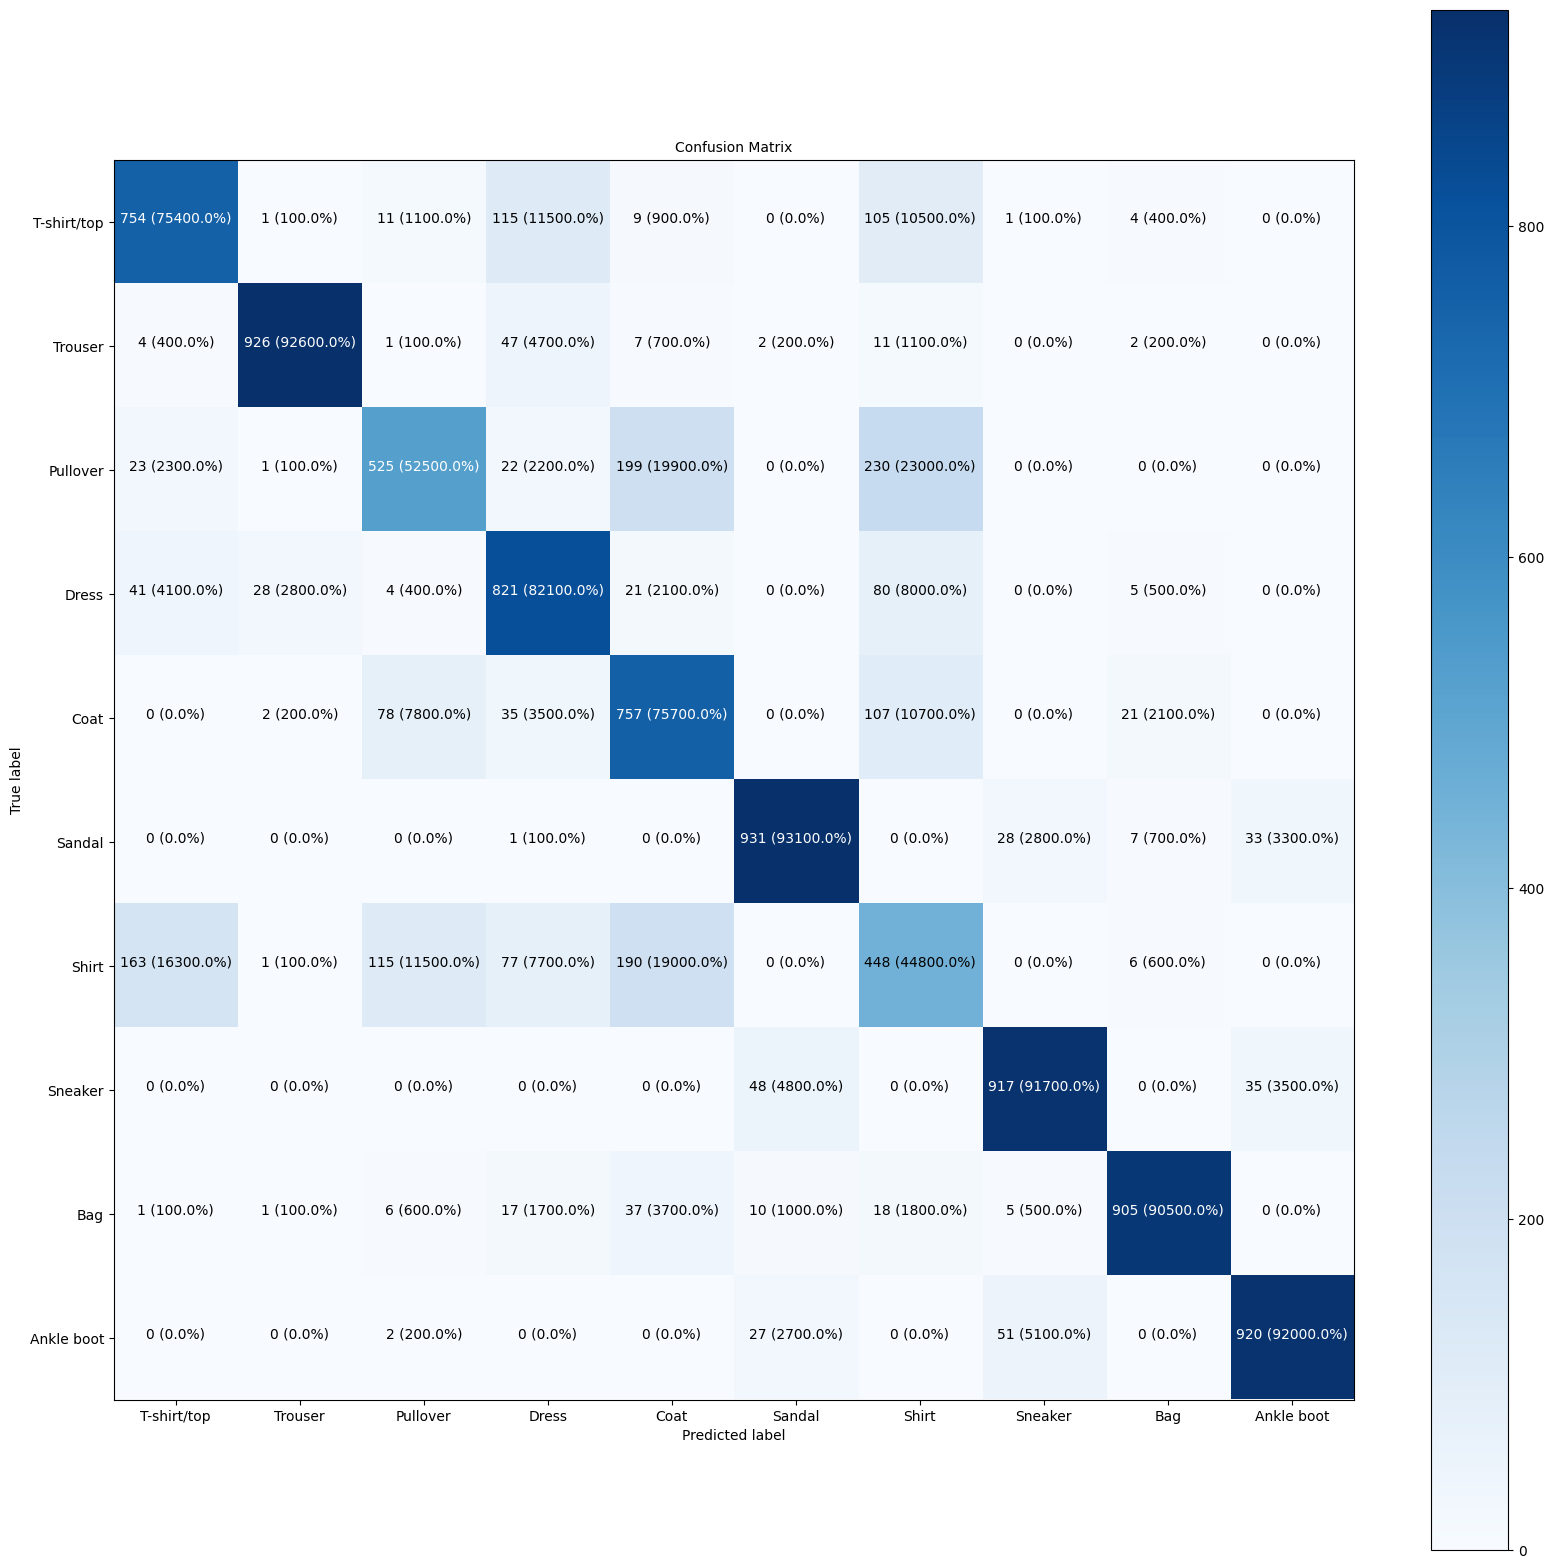

In [ ]:
#Make a prettier confusion matrix
make_confusion_matrix(y_true = test_labels,
                      y_pred = y_preds,
                      classes = class_names,
                      figsize=(20,20),
                      text_size=10)

**Note:** Often when your working with images and other forms of visual data, it's good idea to visualize as much as possible to develop a further understanding of the data and the inputs and outputs of your models.

How about we create a fun little function for:
* Plot a random image
* Make a prediction on said image
* Label the plot with the truth label & the predicted label

In [ ]:
import random

def plot_random_image(model , images , true_labels , classes):
  """
  Picks a random image , plots it and labels it with a prediction and truth label.
  """

  #Set up random integer
  i = random.randint(0 , len(images))

  #Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1 , 28 , 28))
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  #Plot the image
  plt.imshow(target_image , cmap=plt.cm.binary)

  #Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  #Add xlabel information (prediction/true label)
  plt.xlabel("pred: {} {:2.0}% (True: {})" .format(pred_label,
                                                   100*tf.reduce_max(pred_probs),
                                                   true_label),
             color = color)# set the color to green or red based on if prediction is right or wrong

In [ ]:
#Check out a random image as well as it's prediction
plot_random_image(model = model_14,
                  images = test_data_norm, #always make predictions on the same kind of data your model was trained on
                  true_labels = test_labels,
                  classes = class_names)

NameError: name 'model_14' is not defined

# What patterns is our model learning?

In [ ]:
#Find the layers of our most recent model
model_14.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_35, built=True>,
 <Dense name=dense_36, built=True>,
 <Dense name=dense_37, built=True>]

In [ ]:
#Extract a particular layer
model_14.layers[1]

<Dense name=dense_35, built=True>

In [ ]:
#Get the patterns of a layer in our network
weights , biases = model_14.layers[1].get_weights()

# shapes
weights , weights.shape

(array([[ 0.33259475,  0.08035658, -0.6550483 ,  0.03561503],
        [-0.09591786,  0.31593516, -0.14500855, -0.51745623],
        [-1.3886464 ,  0.2762631 , -0.17256215, -0.5640317 ],
        ...,
        [-0.6169498 , -0.02403224,  0.2694042 ,  0.30760595],
        [-0.80313706,  0.5037035 , -0.02224303,  0.02021556],
        [-0.7486716 ,  0.06115657, -0.07368285,  0.53014374]],
       dtype=float32),
 (784, 4))

In [ ]:
model_14.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

Let's check out the bias vector...

In [ ]:
#Bias and biases shapes
biases , biases.shape

(array([2.0847163, 1.6012667, 1.5507787, 0.7866002], dtype=float32), (4,))

Every neuron has a bias vector. Each of these is paired with a weights matrix.

The bias vector get initialized as zeros(at least in the case of a TensorFlow Dense layer).

The bias vector dictates how much the patterns within the corresponding weights matrix should influence the next layer.

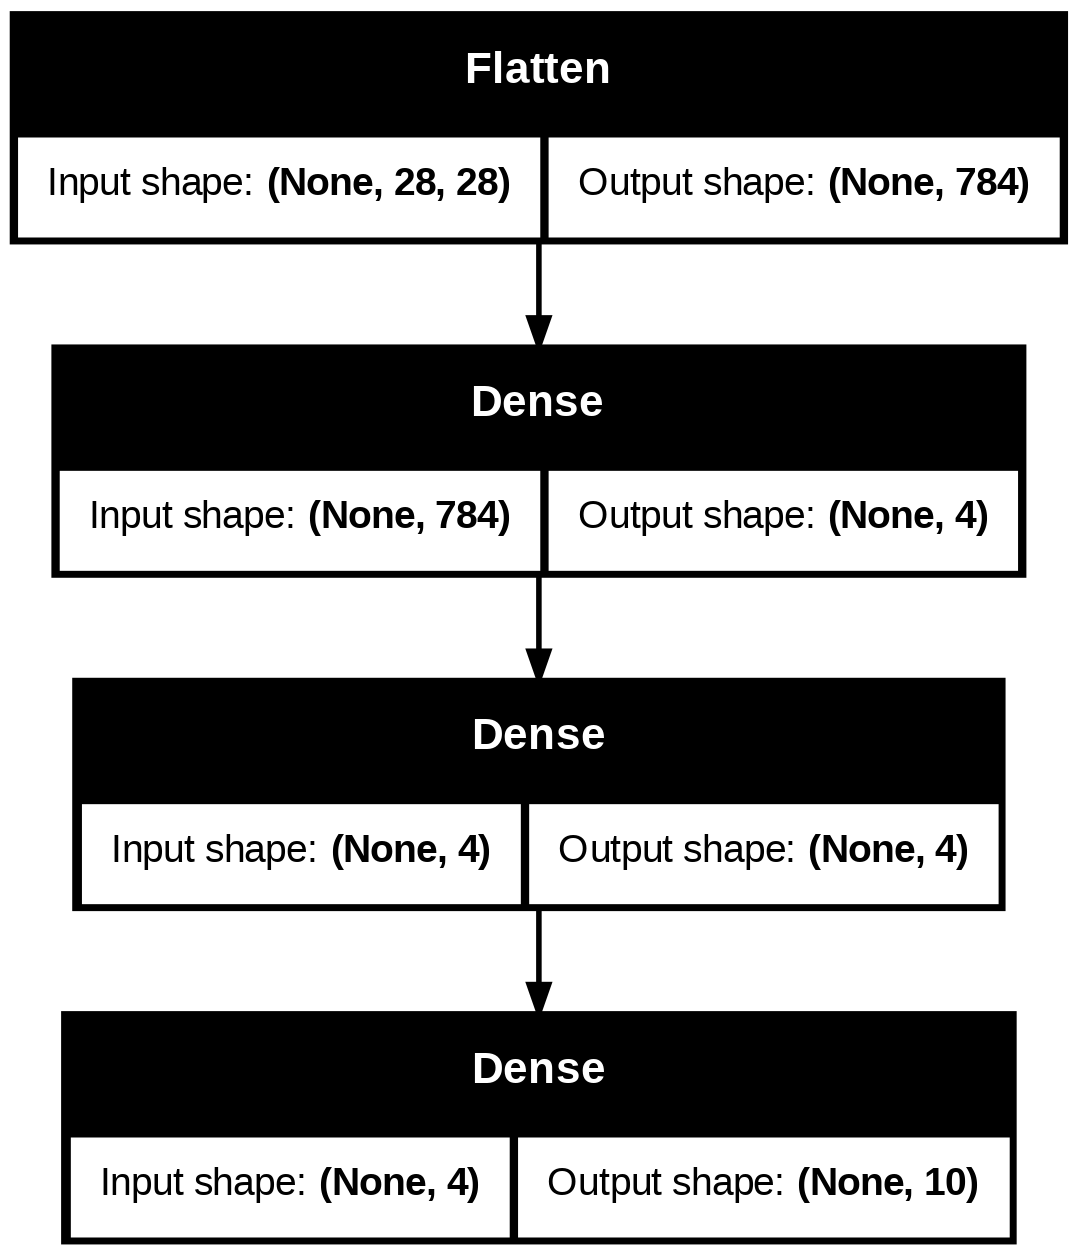

In [ ]:
#let's check out another way of viewing our deep learning models
from tensorflow.keras.utils import plot_model
#See the inputs and outputs of each layer
plot_model(model_14 , show_shapes=True)